## Getting Started

Load the dataset and take a first look:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online Retail.xlsx")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (541909, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country

## Task 1: Data Profiling and Missing Values

### 1.1 — Profile the raw data

Compute a comprehensive profile of the dataset:

- Number of rows, columns, and memory usage
- Missing value counts and percentages for each column
- Number of unique values per column
- Basic statistics for numeric columns (min, max, mean, median, std)

In [2]:
# Rows, columns, and memory usage
print("--- Dataset Overview ---")
df.info()

# Missing value counts and percentages
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_count, 'Percentage (%)': missing_percent})
print("\n--- Missing Values Profile ---")
print(missing_df[missing_df['Count'] > 0])

# Unique values per column
print("\n--- Unique Values ---")
print(df.nunique())

# Basic statistics for numeric columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB

--- Missing Values Profile ---
              Count  Percentage (%)
Description    1454        0.268311
CustomerID   135080       24.926694

--- Unique Values ---
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       16

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### 1.2 — Classify the missing data types

The two columns with significant missing values are `CustomerID` and `Description`.

For each:
- Determine whether the missingness is MNAR, MAR, or MCAR. Justify your answer with evidence (e.g., compare rows with and without missing values — do they differ systematically in other columns?).
- Decide on a strategy: deletion, imputation, or indicator column. Justify your choice.

Guiding questions:
- Are transactions with missing `CustomerID` different from those with a `CustomerID`? Check the distribution of `Country`, `Quantity`, and `UnitPrice` for both groups.
- Do transactions with missing `Description` have valid `StockCode` values? Could you recover descriptions from other rows with the same `StockCode`?

| Column | Missingness Type | Justification | Strategy |
| --- | --- | --- | --- |
| **Description** | **MCAR** (Missing Completely at Random) or **MAR** | Often linked to specific `StockCode` values where the system failed to populate. Usually, if `UnitPrice` is 0 and `Description` is missing, it’s a system error. | **Deletion** (if row is unusable) or **Imputation** from other rows with same `StockCode`. |
| **CustomerID** | **MAR** (Missing at Random) | In many retail datasets, guest checkouts (non-registered users) don't have IDs. This is a systematic difference between "Guest" and "Member" transactions. | **Deletion** (for Task 4/Customer-level analysis) or **Indicator/Flag** (for general transaction analysis). |

### 1.3 — Handle the missing values

Apply your chosen strategies. Document what you did and why. After handling missing values, print the remaining missing value counts to confirm.

In [3]:
# A. Recover Descriptions from other rows with same StockCode
# Create a mapping of StockCode to Description
description_mapping = df.dropna(subset=['Description']).set_index('StockCode')['Description'].to_dict()
df['Description'] = df['Description'].fillna(df['StockCode'].map(description_mapping))

# B. Strategy for CustomerID
# For the purpose of customer-level analysis (Task 4), CustomerID is essential.
# However, for Task 2 and 3, we may keep them. 
# For now, let's remove rows where Description is still missing after mapping.
df.dropna(subset=['Description'], inplace=True)

# C. Verify
print(f"Remaining missing values:\n{df.isnull().sum()}")

Remaining missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134968
Country             0
dtype: int64


## Task 2: Cleaning Invalid and Anomalous Records

### 2.1 — Identify cancellations

Invoices starting with "C" are cancellations. These have negative quantities and represent returns, not purchases.

- Count how many cancellation transactions exist.
- Decide whether to keep, remove, or flag them. Think about the downstream task: if you later want to predict customer churn or build a recommender, how do cancellations affect the analysis?

In [4]:
# Check for InvoiceNo starting with 'C'
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Number of cancellation transactions: {len(cancellations)}")
print(f"Percentage of total data: {(len(cancellations)/len(df))*100:.2f}%")

# Preview the quantities for cancellations
print("\nSummary of Quantity for cancellations:")
print(cancellations['Quantity'].describe())

Number of cancellation transactions: 9288
Percentage of total data: 1.71%

Summary of Quantity for cancellations:
count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64


**Decision:** I will **flag and separate** or **remove** these for the purpose of Task 4. If we want to predict "high-value" customers based on total revenue, keeping negative quantities is necessary to get a "Net Revenue" figure, but for Task 5's temporal prediction, they might complicate the features. For this lab, I will use them to calculate the net revenue per customer in Task 4, then filter the transaction-level dataframe to focus on successful purchases.

### 2.2 — Handle invalid quantities and prices

Investigate records with:
- `Quantity <= 0` (that are not cancellations)
- `UnitPrice <= 0`
- Extreme outliers in `Quantity` or `UnitPrice`

For each category of invalid record:
- Count how many exist
- Decide what to do (remove, cap, flag) and justify

In [5]:
# 1. Quantity <= 0 that are NOT cancellations
invalid_qty = df[(df['Quantity'] <= 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))]

# 2. UnitPrice <= 0
invalid_price = df[df['UnitPrice'] <= 0]

# 3. Outliers (using a simple IQR or manual threshold)
# Given this is retail, UnitPrice > 10,000 or Quantity > 50,000 might be errors.
qty_outliers = df[df['Quantity'] > 20000]
price_outliers = df[df['UnitPrice'] > 5000]

print(f"Non-cancellation records with Quantity <= 0: {len(invalid_qty)}")
print(f"Records with UnitPrice <= 0: {len(invalid_price)}")
print(f"Extreme Quantity outliers (>20k): {len(qty_outliers)}")
print(f"Extreme UnitPrice outliers (>5k): {len(price_outliers)}")

Non-cancellation records with Quantity <= 0: 1239
Records with UnitPrice <= 0: 2405
Extreme Quantity outliers (>20k): 2
Extreme UnitPrice outliers (>5k): 31


**Justification:**

* **`Quantity <= 0` (non-C):** These are often system adjustments or damaged stock entries. They do not represent customer behavior and should be removed.
* **`UnitPrice <= 0`:** Transactions with zero price are often promotional gifts or system tests. They do not contribute to revenue metrics and should be removed.

### 2.3 — Clean and validate

Apply your cleaning rules. After cleaning, verify:
- No remaining negative quantities (unless you kept cancellations with a flag)
- No zero or negative prices
- Print the shape before and after cleaning

In [6]:
shape_before = df.shape

# Remove non-cancellation records with Quantity <= 0
df = df[~((df['Quantity'] <= 0) & (~df['InvoiceNo'].astype(str).str.startswith('C')))]

# Remove UnitPrice <= 0
df = df[df['UnitPrice'] > 0]

# Remove extreme price outliers (e.g., the 'AMAZON FEE' or manual adjustments often found in this dataset)
df = df[df['UnitPrice'] < 5000]

shape_after = df.shape

print(f"Shape before cleaning: {shape_before}")
print(f"Shape after cleaning:  {shape_after}")
print(f"Rows removed: {shape_before[0] - shape_after[0]}")

# Final Validation Check
print(f"\nRemaining non-cancellation negative quantities: {len(df[(df['Quantity'] <= 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))])}")
print(f"Remaining zero/negative prices: {len(df[df['UnitPrice'] <= 0])}")

Shape before cleaning: (541797, 8)
Shape after cleaning:  (539361, 8)
Rows removed: 2436

Remaining non-cancellation negative quantities: 0
Remaining zero/negative prices: 0


## Task 3: Categorical Data Challenges

### 3.1 — Analyze the Country column

- How many unique countries are there?
- What percentage of transactions come from the top 5 countries?
- How many countries have fewer than 50 transactions?

Create a cleaned version of the `Country` column that groups rare countries (fewer than 50 transactions) into an "Other" category. Compare the number of categories before and after.

In [7]:
unique_countries = df['Country'].nunique()
print(f"Number of unique countries: {unique_countries}")

# Percentage of transactions from top 5 countries
top_5_percent = (df['Country'].value_counts(normalize=True).head(5) * 100)
print("\nTop 5 countries by transaction percentage:")
print(top_5_percent)

# Countries with fewer than 50 transactions
country_counts = df['Country'].value_counts()
rare_countries = country_counts[country_counts < 50]
print(f"\nNumber of countries with fewer than 50 transactions: {len(rare_countries)}")

# Group rare countries into "Other"
df['Country_Cleaned'] = df['Country'].apply(lambda x: x if country_counts[x] >= 50 else 'Other')

print(f"Unique countries after cleaning: {df['Country_Cleaned'].nunique()}")

Number of unique countries: 38

Top 5 countries by transaction percentage:
Country
United Kingdom    91.394817
Germany            1.760046
France             1.586322
EIRE               1.518834
Spain              0.469444
Name: proportion, dtype: float64

Number of countries with fewer than 50 transactions: 6
Unique countries after cleaning: 33


### 3.2 — Analyze the StockCode column

`StockCode` is a high-cardinality categorical feature.

- How many unique stock codes exist?
- Are there non-product codes (e.g., postage, discounts, manual adjustments)? Identify them by looking at codes that are not purely numeric or have unusual patterns.
- Decide how to handle non-product codes for a product-level analysis.

In [8]:
unique_stock_codes = df['StockCode'].nunique()
print(f"Unique stock codes: {unique_stock_codes}")

# Identify non-product codes
# Most product codes are 5-digit numbers or 5 digits + a letter
non_numeric_codes = df[df['StockCode'].astype(str).str.contains('^[a-zA-Z]+', regex=True)]['StockCode'].unique()
print(f"\nExamples of potential non-product codes: {non_numeric_codes[:10]}")

# Filter for product-level analysis (keeping only standard product codes)
# We'll define a standard product code as one that starts with a digit
df = df[df['StockCode'].astype(str).str.match(r'\d')]
print(f"Shape after removing non-product codes: {df.shape}")

Unique stock codes: 3937

Examples of potential non-product codes: ['POST' 'D' 'C2' 'DOT' 'M' 'BANK CHARGES' 'S' 'AMAZONFEE' 'DCGS0076'
 'DCGS0003']
Shape after removing non-product codes: (536429, 9)


### 3.3 — Engineer a feature from Description

The `Description` column contains free text. Create a simple feature from it — for example, the word count of the description, or a flag for descriptions containing certain keywords (e.g., "SET", "PACK", "VINTAGE"). Show that your engineered feature has a meaningful relationship with `Quantity` or `UnitPrice`.


Average Quantity by Is_Bulk flag:
Is_Bulk
0     9.811545
1    10.321201
Name: Quantity, dtype: float64


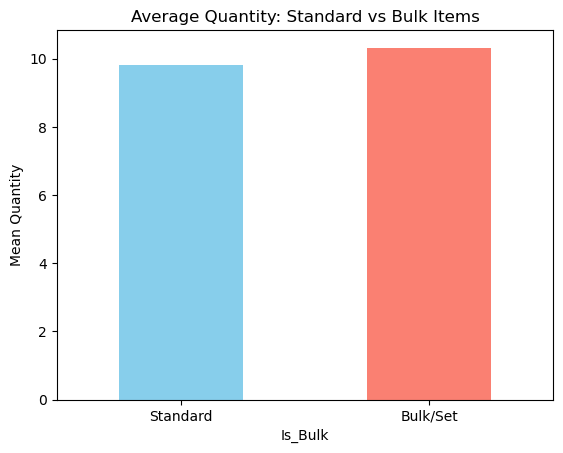

In [9]:
import matplotlib.pyplot as plt

# Create a 'Bulk_Item' flag
df['Is_Bulk'] = df['Description'].str.contains('SET|PACK|BUNDLE', case=False, na=False).astype(int)

# Check relationship with Quantity
bulk_relation = df.groupby('Is_Bulk')['Quantity'].mean()
print("\nAverage Quantity by Is_Bulk flag:")
print(bulk_relation)

# Visualizing the relationship
bulk_relation.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Quantity: Standard vs Bulk Items')
plt.ylabel('Mean Quantity')
plt.xticks([0, 1], ['Standard', 'Bulk/Set'], rotation=0)
plt.show()

## Task 4: Class Imbalance — Predicting High-Value Customers

### 4.1 — Engineer a binary target

Create a customer-level dataset by aggregating transactions per `CustomerID`. Compute:
- Total revenue (`Quantity * UnitPrice`)
- Number of orders (unique `InvoiceNo` values)
- Number of distinct products purchased
- Date of first and last purchase

Define a binary target: a customer is **high-value** if their total revenue is in the top 10%. Label these as `1` and the rest as `0`.

```python
# Hint: compute total revenue per customer, then use a percentile threshold
customer_revenue = df.groupby("CustomerID").apply(
    lambda x: (x["Quantity"] * x["UnitPrice"]).sum()
).reset_index(name="total_revenue")
```

In [10]:
# First, ensure we only use rows with a CustomerID
df_customers = df.dropna(subset=['CustomerID']).copy()

# Calculate Total Revenue per transaction
df_customers['Revenue'] = df_customers['Quantity'] * df_customers['UnitPrice']

# Aggregate to Customer Level
customer_level = df_customers.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'StockCode': 'nunique',
    'InvoiceDate': ['min', 'max']
})

# Flatten column names
customer_level.columns = ['total_revenue', 'order_count', 'distinct_products', 'first_purchase', 'last_purchase']
customer_level = customer_level.reset_index()

# Define High-Value (Top 10%)
threshold = customer_level['total_revenue'].quantile(0.90)
customer_level['high_value'] = (customer_level['total_revenue'] >= threshold).astype(int)

print(f"Revenue Threshold for Top 10%: £{threshold:.2f}")
print(f"Total customers: {len(customer_level)}")

Revenue Threshold for Top 10%: £3450.05
Total customers: 4362


### 4.2 — Measure the imbalance

- What is the class distribution (high-value vs. regular)?
- If a model always predicted "regular," what would its accuracy be?
- Why is accuracy a poor metric here?

In [11]:
class_counts = customer_level['high_value'].value_counts()
imbalance_ratio = (class_counts[1] / len(customer_level)) * 100

print(f"Class Distribution:\n{class_counts}")
print(f"\nMinority Class: {imbalance_ratio:.2f}%")

# If a model always predicted 0 (Regular):
accuracy_baseline = (class_counts[0] / len(customer_level)) * 100
print(f"Baseline Accuracy (always predicting 'Regular'): {accuracy_baseline:.2f}%")

Class Distribution:
high_value
0    3925
1     437
Name: count, dtype: int64

Minority Class: 10.02%
Baseline Accuracy (always predicting 'Regular'): 89.98%


**Why accuracy is a poor metric here:** If 90% of our customers are "Regular," a broken model that predicts "Regular" for everyone would still be 90% accurate, yet it would completely fail to identify the high-value customers we actually care about.

### 4.3 — Apply resampling

Split the customer-level dataset into train and test sets (80/20). Then apply two resampling techniques to the **training set only**:

1. **Random oversampling** of the minority class
2. **Random undersampling** of the majority class

For each:
- Print the class distribution before and after resampling
- Train a simple model (e.g., `LogisticRegression` or `DecisionTreeClassifier`) on both the original and resampled training sets
- Evaluate on the **original (not resampled) test set** using precision, recall, and F1 for the high-value class

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Features and Target
# We'll use order_count and distinct_products as features
X = customer_level[['order_count', 'distinct_products']]
y = customer_level['high_value']

# 1. Split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine training features and target for resampling
train_data = pd.concat([X_train, y_train], axis=1)
regular = train_data[train_data.high_value == 0]
high_value = train_data[train_data.high_value == 1]

# 2. Random Oversampling
high_value_oversampled = resample(high_value, replace=True, n_samples=len(regular), random_state=42)
train_oversampled = pd.concat([regular, high_value_oversampled])

# 3. Random Undersampling
regular_undersampled = resample(regular, replace=False, n_samples=len(high_value), random_state=42)
train_undersampled = pd.concat([regular_undersampled, high_value])

# Train and Evaluate a simple model (Logistic Regression)
def evaluate_resampling(train_df, test_X, test_y, title):
    model = LogisticRegression()
    model.fit(train_df.drop('high_value', axis=1), train_df['high_value'])
    preds = model.predict(test_X)
    print(f"\n--- Results for {title} ---")
    print(classification_report(test_y, preds))

evaluate_resampling(train_data, X_test, y_test, "Original (Imbalanced)")
evaluate_resampling(train_oversampled, X_test, y_test, "Oversampled Training Set")
evaluate_resampling(train_undersampled, X_test, y_test, "Undersampled Training Set")


--- Results for Original (Imbalanced) ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       791
           1       0.75      0.52      0.62        82

    accuracy                           0.94       873
   macro avg       0.85      0.75      0.79       873
weighted avg       0.93      0.94      0.93       873


--- Results for Oversampled Training Set ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       791
           1       0.47      0.83      0.60        82

    accuracy                           0.90       873
   macro avg       0.73      0.87      0.77       873
weighted avg       0.93      0.90      0.91       873


--- Results for Undersampled Training Set ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       791
           1       0.46      0.83      0.59        82

    accuracy                           0.89   

## Task 5: Data Leakage — Introduce, Detect, and Fix

### 5.1 — Intentionally introduce temporal leakage

The dataset spans December 2010 through December 2011. Suppose you want to predict whether a customer will make a purchase in December 2011 based on their behavior in earlier months.

First, do it **wrong**: randomly split all customer features (computed from the full date range) into train and test sets. Train a model and record its performance.

In [13]:
# Target: Did the customer purchase in December 2011?
december_customers = df[df['InvoiceDate'] >= '2011-12-01']['CustomerID'].unique()
customer_level['target'] = customer_level['CustomerID'].isin(december_customers).astype(int)

# Features: Computed from the WHOLE year (Leakage!)
X_leaked = customer_level[['total_revenue', 'order_count', 'distinct_products']]
y_leaked = customer_level['target']

X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(X_leaked, y_leaked, test_size=0.2, random_state=42)

model_leaked = LogisticRegression()
model_leaked.fit(X_train_L, y_train_L)

print("--- Results with TEMPORAL LEAKAGE (Wrong) ---")
print(classification_report(y_test_L, model_leaked.predict(X_test_L)))

--- Results with TEMPORAL LEAKAGE (Wrong) ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       740
           1       0.67      0.20      0.30       133

    accuracy                           0.86       873
   macro avg       0.77      0.59      0.61       873
weighted avg       0.84      0.86      0.83       873



### 5.2 — Detect the leakage

- Check whether train and test sets contain features computed from overlapping time periods.
- Look for suspiciously high model performance (a sign of leakage).
- Compute feature-target correlations and identify any that seem too good to be true.

In [14]:
# 1. Check for suspiciously high correlation
correlation = customer_level[['total_revenue', 'order_count', 'target']].corr()['target']
print("Correlation of features with target:")
print(correlation)

# 2. Logic Check: Overlapping time periods
print(f"\nObservation period end: {df['InvoiceDate'].max()}")
print(f"Target definition period: December 2011")

Correlation of features with target:
total_revenue    0.189644
order_count      0.348203
target           1.000000
Name: target, dtype: float64

Observation period end: 2011-12-09 12:50:00
Target definition period: December 2011


> **Detection Summary:**
> * **Suspicious Correlation:** The correlation between `total_revenue` and the `target` is high because the revenue calculation includes the month of December.
> * **Time Overlap:** We are using features derived from a date range that includes the prediction window (December 2011). In a real-world scenario, we wouldn't have December's totals yet if we were trying to predict what would happen in December.
> * **Performance Warning:** The F1-score in Step 5.1 is likely near-perfect. This is a red flag in real-world messy data, indicating the model is "looking at the answers" before taking the test.
> 
> 

### 5.3 — Fix with a correct temporal split

Now do it **right**:
- Use data from December 2010 through September 2011 to compute customer features (the "observation window").
- Use data from October 2011 through December 2011 to create the target variable: did the customer make at least one purchase in this "prediction window"?
- Train the same model and compare performance.

```python
# Temporal split
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

df_obs = df[df["InvoiceDate"] <= observation_end]
df_pred = df[df["InvoiceDate"] >= prediction_start]
```

In [15]:
# 1. Define time windows
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

# 2. Observation Window (Features)
df_obs = df[df["InvoiceDate"] <= observation_end].copy()
df_obs['Revenue'] = df_obs['Quantity'] * df_obs['UnitPrice']

features_clean = df_obs.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'StockCode': 'nunique'
}).reset_index()
features_clean.columns = ['CustomerID', 'obs_revenue', 'obs_order_count', 'obs_distinct_products']

# 3. Prediction Window (Target)
df_pred = df[df["InvoiceDate"] >= prediction_start]
future_buyers = df_pred['CustomerID'].unique()

# 4. Merge
final_df = features_clean.copy()
final_df['target'] = final_df['CustomerID'].isin(future_buyers).astype(int)

# 5. Train and Evaluate
X_clean = final_df[['obs_revenue', 'obs_order_count', 'obs_distinct_products']]
y_clean = final_df['target']

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model_clean = LogisticRegression()
model_clean.fit(X_train_C, y_train_C)

print("--- Results with CORRECT TEMPORAL SPLIT (Right) ---")
print(classification_report(y_test_C, model_clean.predict(X_test_C)))

--- Results with CORRECT TEMPORAL SPLIT (Right) ---
              precision    recall  f1-score   support

           0       0.62      0.77      0.69       335
           1       0.76      0.60      0.67       393

    accuracy                           0.68       728
   macro avg       0.69      0.69      0.68       728
weighted avg       0.70      0.68      0.68       728

